# Face2Comic — Hyperparameter tuning (pix2pix)

Train real→comic with paired `.npy` data: build G/D, sweep **LR / batch / λ_L1** on subsets, visualize the grid, reuse the winner for full training elsewhere.

In [1]:
import sys
sys.path.insert(0, "..")

import csv
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image
from torchinfo import summary

from src.config import SEED, NUM_WORKERS, set_seed, get_device
from src.data import load_data, make_datasets, make_loaders
from src.models import Generator, Discriminator
from src.training import make_models, train_one_epoch, validate
from src.visualization import denorm, save_grid_samples

set_seed(SEED)
print(f"Random seed: {SEED}")
print(f"Number of workers: {NUM_WORKERS}")

Random seed: 42
Number of workers: 0


## Device
`get_device()` → CUDA, else MPS (Apple), else CPU.

In [2]:
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: cuda


## 1. Load data
Memory-mapped pairs from preprocessing: **256×256**, **CHW**, values in **[-1, 1]**.

In [3]:
data = load_data("../data/npy")

print(f"Train — real: {data['train_real'].shape}, comic: {data['train_comic'].shape}")
print(f"Val   — real: {data['val_real'].shape},   comic: {data['val_comic'].shape}")
print(f"Test  — real: {data['test_real'].shape},  comic: {data['test_comic'].shape}")
print(f"Pixel range: [{data['train_real'][0].min():.1f}, {data['train_real'][0].max():.1f}]")

Train — real: (8000, 3, 256, 256), comic: (8000, 3, 256, 256)
Val   — real: (1000, 3, 256, 256),   comic: (1000, 3, 256, 256)
Test  — real: (1000, 3, 256, 256),  comic: (1000, 3, 256, 256)
Pixel range: [-1.0, 1.0]


## 2. Dataset & loaders
**Tuning:** first **2000** train / **500** val samples per epoch for speed. Full train & val splits stay available for downstream notebooks; **test** stays held out for evaluation only.

In [4]:
datasets = make_datasets(data, use_train_augmentation=True)

train_dataset = datasets["train"]
full_val_dataset = datasets["val"]
full_test_dataset = datasets["test"]
train_tuning_dataset = datasets["train_tuning"]
val_tuning_dataset = datasets["val_tuning"]

print(f"Train samples (full): {len(train_dataset)}")
print(f"Train samples (tuning subset): {len(train_tuning_dataset)}")
print(f"Val samples (full): {len(full_val_dataset)}")
print(f"Val samples (tuning subset): {len(val_tuning_dataset)}")
print(f"Test samples (full): {len(full_test_dataset)}")

Train samples (full): 8000
Train samples (tuning subset): 2000
Val samples (full): 1000
Val samples (tuning subset): 500
Test samples (full): 1000


/home/gwr4170/.conda/envs/pix2pix/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/projects/e32706/gwr4170/notebooks/../src/data.py:63: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
/projects/e32706/gwr4170/notebooks/../src/data.py:75: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=20, max_width=20, p=0.3),


## 3. Generator (U-Net)
Encoder–decoder with **skips**. Down: stride-2 convs + InstanceNorm + LeakyReLU. Up: transpose conv + norm + ReLU (early dropout). **Tanh** → [-1, 1].

In [5]:
generator = Generator()
summary(generator, input_size=(1, 3, 256, 256))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [1, 3, 256, 256]          --
├─UNetDown: 1-1                          [1, 64, 128, 128]         --
│    └─Sequential: 2-1                   [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-1                  [1, 64, 128, 128]         3,072
│    │    └─LeakyReLU: 3-2               [1, 64, 128, 128]         --
├─UNetDown: 1-2                          [1, 128, 64, 64]          --
│    └─Sequential: 2-2                   [1, 128, 64, 64]          --
│    │    └─Conv2d: 3-3                  [1, 128, 64, 64]          131,072
│    │    └─InstanceNorm2d: 3-4          [1, 128, 64, 64]          --
│    │    └─LeakyReLU: 3-5               [1, 128, 64, 64]          --
├─UNetDown: 1-3                          [1, 256, 32, 32]          --
│    └─Sequential: 2-3                   [1, 256, 32, 32]          --
│    │    └─Conv2d: 3-6                  [1, 256, 32, 32]          524,288
│ 

## 4. Discriminator (PatchGAN)
Channels **concat**(real photo, target or fake comic) → patch-level real/fake logits (see `torchinfo`).

In [6]:
discriminator = Discriminator()
summary(discriminator, input_size=[(1, 3, 256, 256), (1, 3, 256, 256)])

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1, 30, 30]            --
├─Sequential: 1-1                        [1, 1, 30, 30]            --
│    └─Conv2d: 2-1                       [1, 64, 128, 128]         6,144
│    └─LeakyReLU: 2-2                    [1, 64, 128, 128]         --
│    └─Conv2d: 2-3                       [1, 128, 64, 64]          131,072
│    └─BatchNorm2d: 2-4                  [1, 128, 64, 64]          256
│    └─LeakyReLU: 2-5                    [1, 128, 64, 64]          --
│    └─Conv2d: 2-6                       [1, 256, 32, 32]          524,288
│    └─BatchNorm2d: 2-7                  [1, 256, 32, 32]          512
│    └─LeakyReLU: 2-8                    [1, 256, 32, 32]          --
│    └─Conv2d: 2-9                       [1, 512, 31, 31]          2,097,152
│    └─BatchNorm2d: 2-10                 [1, 512, 31, 31]          1,024
│    └─LeakyReLU: 2-11                   [1, 512, 31, 31]   

### Init (pix2pix)
Conv kernels **~N(0, 0.02)**; BatchNorm scale **~N(1, 0.02)**, bias **0**.

In [7]:
_g = Generator()
_d = Discriminator()
print(f"Generator params:     {sum(p.numel() for p in _g.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in _d.parameters()):,}")
del _g, _d

Generator params:     29,238,275
Discriminator params: 2,768,641


## 5. Loss
**G:** adversarial **BCE** + **λ_L1 · L1** to target comic pixels (`G_loss = BCE + λ_L1 × L1`).

## 6. Grid search
**3×3×3 = 27** settings (LR, batch, λ_L1); **10 epochs** each on the tuning subsets. **CSV** appended per run (crash-safe); **lowest val L1** → checkpoint (`best_grid_config.pt`).

In [8]:
GRID_LRS = [1e-4, 2e-4, 5e-4]
GRID_BATCH_SIZES = [16, 32, 64]
GRID_LAMBDA_L1 = [50, 100, 150]
GRID_EPOCHS = 10
GRID_BETAS = (0.5, 0.999)
GRID_PREVIEW_INDICES = [9, 10, 12]

OUTPUT_DIR = Path("output/grid_search_samples+3_hyperparameter_tuning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path("output/grid_search_results+3_hyperparameter_tuning")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

total_configs = len(GRID_LRS) * len(GRID_BATCH_SIZES) * len(GRID_LAMBDA_L1)
print(f"Grid search: {total_configs} configurations, {GRID_EPOCHS} epochs each")

Grid search: 27 configurations, 10 epochs each


In [9]:
GRID_CSV = RESULTS_DIR / "grid_search_results.csv"

with open(GRID_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["config_idx", "learning_rate", "batch_size", "lambda_l1", "val_l1"])
    writer.writeheader()

grid_results = []
best_val_l1 = float("inf")
best_grid_state = None
config_idx = 0

for lr in GRID_LRS:
    for bs in GRID_BATCH_SIZES:
        for lam in GRID_LAMBDA_L1:
            config_idx += 1
            print(f"\n{'='*60}")
            print(f"Config {config_idx}/{total_configs}  LR={lr:.0e}  BS={bs}  λ_L1={lam}")
            print(f"{'='*60}")

            gen, disc, opt_gen, opt_disc = make_models(lr, GRID_BETAS, DEVICE)
            train_loader, val_loader = make_loaders(bs, train_tuning_dataset, val_tuning_dataset, DEVICE)

            for epoch in range(1, GRID_EPOCHS + 1):
                g_loss, d_loss = train_one_epoch(gen, disc, train_loader, opt_gen, opt_disc, lam, DEVICE)
                if epoch % 5 == 0 or epoch == GRID_EPOCHS:
                    print(f"  Epoch {epoch}/{GRID_EPOCHS}  G={g_loss:.4f}  D={d_loss:.4f}")

            val_l1 = validate(gen, val_loader, DEVICE)
            print(f"  Val L1: {val_l1:.6f}")

            save_grid_samples(gen, full_val_dataset, config_idx, OUTPUT_DIR, DEVICE, GRID_PREVIEW_INDICES)

            # show a quick 3-sample preview inline
            preview_indices = [idx for idx in GRID_PREVIEW_INDICES if 0 <= idx < len(full_val_dataset)]
            if not preview_indices:
                preview_indices = list(range(min(3, len(full_val_dataset))))

            gen.eval()
            fig, axes = plt.subplots(len(preview_indices), 3, figsize=(9, 3 * len(preview_indices)), squeeze=False)
            axes[0, 0].set_title("Real")
            axes[0, 1].set_title("Generated")
            axes[0, 2].set_title("Target")
            with torch.no_grad():
                for row, idx in enumerate(preview_indices):
                    real_s, target_s = full_val_dataset[idx]
                    fake_s = gen(real_s.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
                    axes[row, 0].imshow(denorm(real_s).permute(1, 2, 0).numpy())
                    axes[row, 1].imshow(denorm(fake_s).permute(1, 2, 0).numpy())
                    axes[row, 2].imshow(denorm(target_s).permute(1, 2, 0).numpy())
                    for j in range(3):
                        axes[row, j].axis("off")
            fig.suptitle(f"Config {config_idx}  LR={lr:.0e}  BS={bs}  λ={lam}  Val L1={val_l1:.4f}", fontweight="bold")
            plt.tight_layout()
            plt.show()

            row = {"config_idx": config_idx, "learning_rate": lr, "batch_size": bs, "lambda_l1": lam, "val_l1": round(val_l1, 6)}
            grid_results.append(row)

            with open(GRID_CSV, "a", newline="") as f:
                csv.DictWriter(f, fieldnames=row.keys()).writerow(row)

            if val_l1 < best_val_l1:
                best_val_l1 = val_l1
                best_grid_state = {
                    "config_idx": config_idx,
                    "lr": lr, "bs": bs, "lambda_l1": lam,
                    "val_l1": val_l1,
                    "gen_state_dict": gen.state_dict(),
                    "disc_state_dict": disc.state_dict(),
                }

            del gen, disc, opt_gen, opt_disc
            torch.cuda.empty_cache()

# save best grid checkpoint
torch.save(best_grid_state, CHECKPOINT_DIR / "best_grid_config.pt")

print(f"\n{'='*60}")
print("Grid Search Complete!")
print(f"{'='*60}")
print(f"\nBest Config #{best_grid_state['config_idx']}  (Val L1 = {best_val_l1:.6f})")
print(f"  LR:       {best_grid_state['lr']:.0e}")
print(f"  Batch:    {best_grid_state['bs']}")
print(f"  λ_L1:     {best_grid_state['lambda_l1']}")
print(f"\nResults saved to {GRID_CSV}")


Config 1/27  LR=1e-04  BS=16  λ_L1=50


100%|██████████| 125/125 [00:11<00:00, 11.32it/s, D=0.391, G=14.634]


  Epoch 5/10  G=14.4931  D=0.4280


100%|██████████| 125/125 [00:11<00:00, 11.29it/s, D=0.612, G=12.512]


  Epoch 10/10  G=14.6235  D=0.3795
  Val L1: 0.251518


...

100%|██████████| 32/32 [00:10<00:00,  2.93it/s, D=0.744, G=33.998]


  Epoch 5/10  G=38.2352  D=0.5889


100%|██████████| 32/32 [00:11<00:00,  2.78it/s, D=0.656, G=35.604]


  Epoch 10/10  G=36.5126  D=0.5120
  Val L1: 0.236217



Grid Search Complete!

Best Config #23  (Val L1 = 0.226234)
  LR:       5e-04
  Batch:    32
  λ_L1:     100

Results saved to output/grid_search_results+3_hyperparameter_tuning/grid_search_results.csv


## 7. Figures
Brief **read-out** after each chart below.

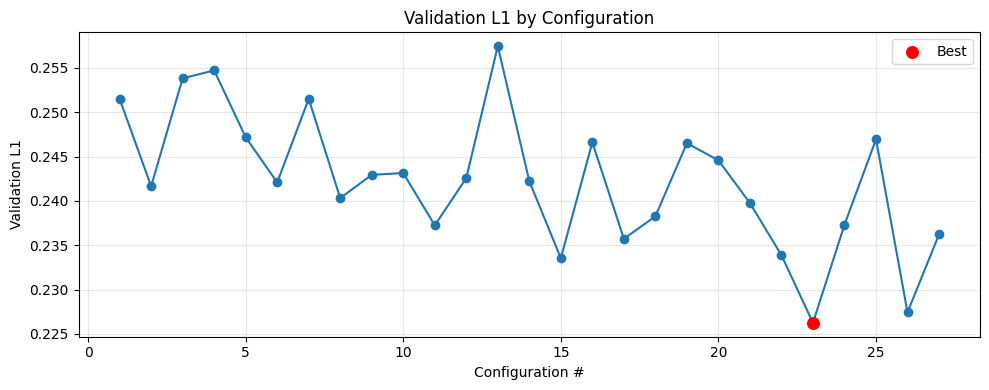

In [10]:
cfg = [r["config_idx"] for r in grid_results]
vals = [r["val_l1"] for r in grid_results]
best_i = vals.index(min(vals))

plt.figure(figsize=(10, 4))
plt.plot(cfg, vals, marker="o", linewidth=1.5)
plt.scatter([cfg[best_i]], [vals[best_i]], color="red", s=70, zorder=3, label="Best")
plt.title("Validation L1 by Configuration")
plt.xlabel("Configuration #")
plt.ylabel("Validation L1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "val_l1_by_config.png", dpi=100)
plt.show()

**Line plot:** Red = argmin val L1. A **wide flat valley** means many configs are OK; a **needle** means the winner is fragile.


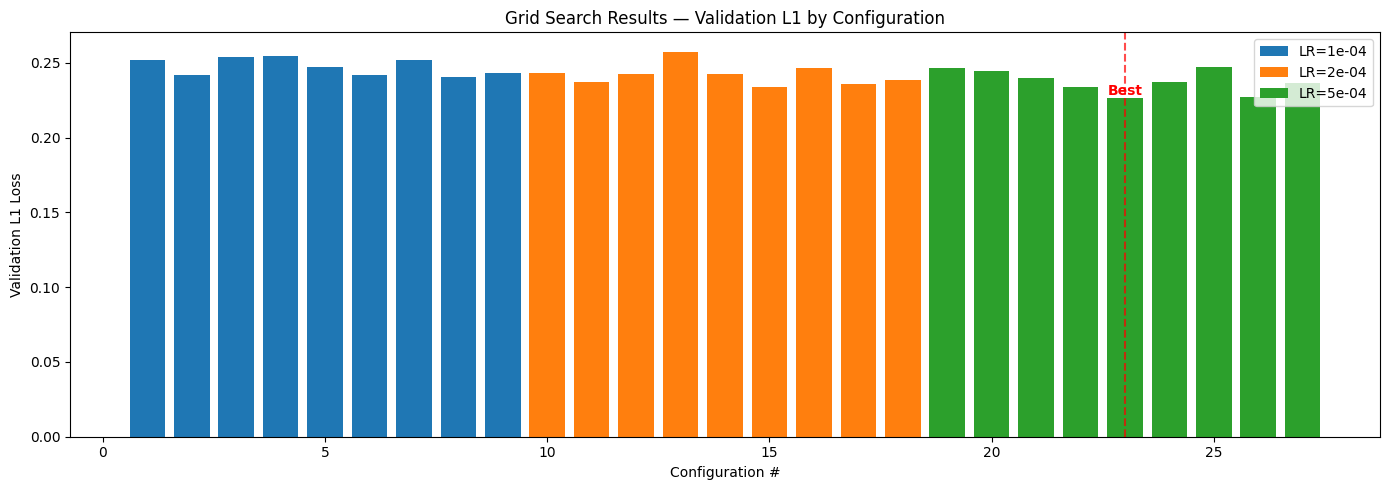

In [11]:
# Bar chart: Val L1 per config, colored by LR
sorted_results = sorted(grid_results, key=lambda r: r["config_idx"])
indices = [r["config_idx"] for r in sorted_results]
val_l1s = [r["val_l1"] for r in sorted_results]
lrs = [r["learning_rate"] for r in sorted_results]

lr_colors = {1e-4: "#1f77b4", 2e-4: "#ff7f0e", 5e-4: "#2ca02c"}
colors = [lr_colors[lr] for lr in lrs]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(indices, val_l1s, color=colors)
ax.set_xlabel("Configuration #")
ax.set_ylabel("Validation L1 Loss")
ax.set_title("Grid Search Results — Validation L1 by Configuration")

legend_elements = [Patch(facecolor=c, label=f"LR={k:.0e}") for k, c in lr_colors.items()]
ax.legend(handles=legend_elements)

best_idx = min(sorted_results, key=lambda r: r["val_l1"])["config_idx"]
ax.axvline(best_idx, color="red", linestyle="--", alpha=0.7, label="Best")
ax.annotate("Best", xy=(best_idx, min(val_l1s)), fontsize=10, color="red",
            ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bar_chart_val_l1.png", dpi=100)
plt.show()

**Bar chart:** Color = LR. If one hue sits lower overall, that LR band generalizes across batch/λ in this sweep.


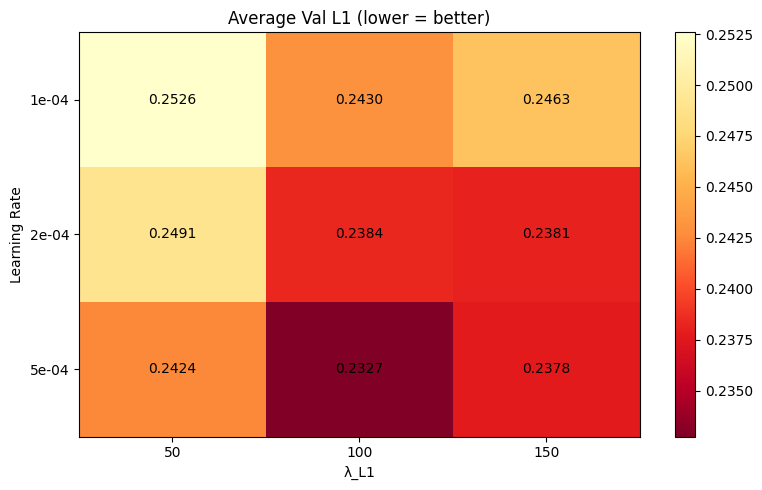

In [12]:
# Heatmap: Val L1 averaged over batch sizes, as (LR × λ_L1)
heatmap_data = {}
for r in grid_results:
    key = (r["learning_rate"], r["lambda_l1"])
    heatmap_data.setdefault(key, []).append(r["val_l1"])

lr_vals = sorted(set(r["learning_rate"] for r in grid_results))
lam_vals = sorted(set(r["lambda_l1"] for r in grid_results))

heat = np.zeros((len(lr_vals), len(lam_vals)))
for i, lr in enumerate(lr_vals):
    for j, lam in enumerate(lam_vals):
        heat[i, j] = np.mean(heatmap_data[(lr, lam)])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat, cmap="YlOrRd_r", aspect="auto")
ax.set_xticks(range(len(lam_vals)))
ax.set_xticklabels([str(int(v)) for v in lam_vals])
ax.set_yticks(range(len(lr_vals)))
ax.set_yticklabels([f"{v:.0e}" for v in lr_vals])
ax.set_xlabel("λ_L1")
ax.set_ylabel("Learning Rate")
ax.set_title("Average Val L1 (lower = better)")

for i in range(len(lr_vals)):
    for j in range(len(lam_vals)):
        ax.text(j, i, f"{heat[i, j]:.4f}", ha="center", va="center", fontsize=10)

fig.colorbar(im)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_lr_lambda.png", dpi=100)
plt.show()

**Heatmap:** Each cell **averages batch sizes** — use it to pick LR×λ first; tune batch from the per-config bars/lines.


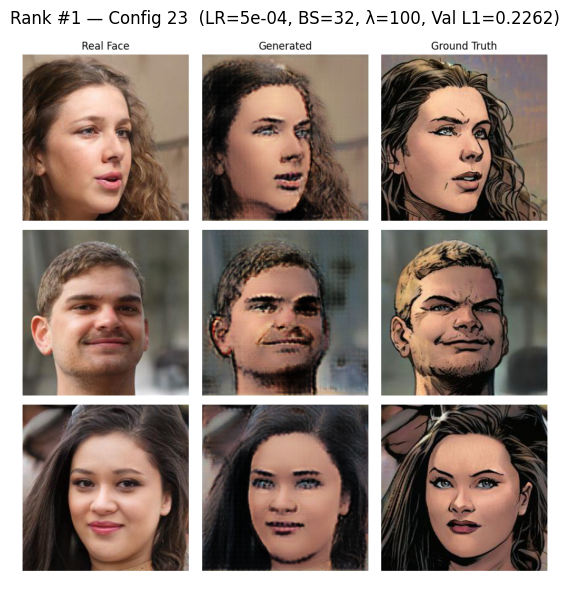

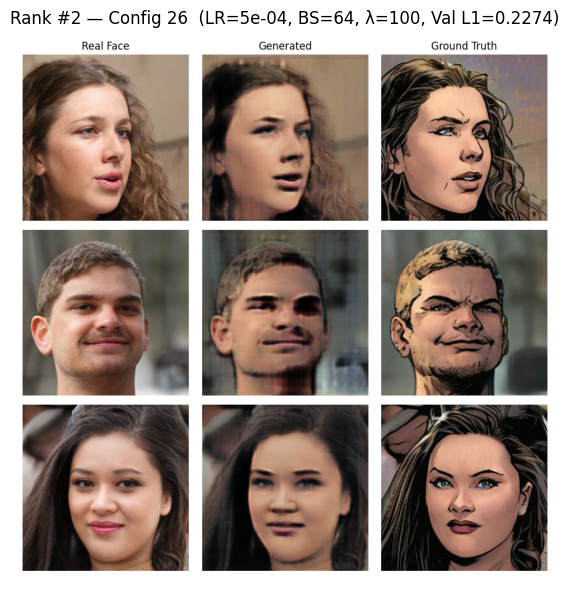

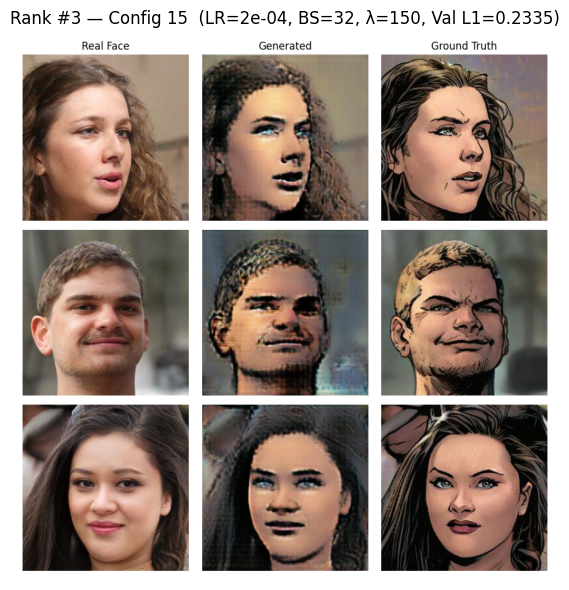

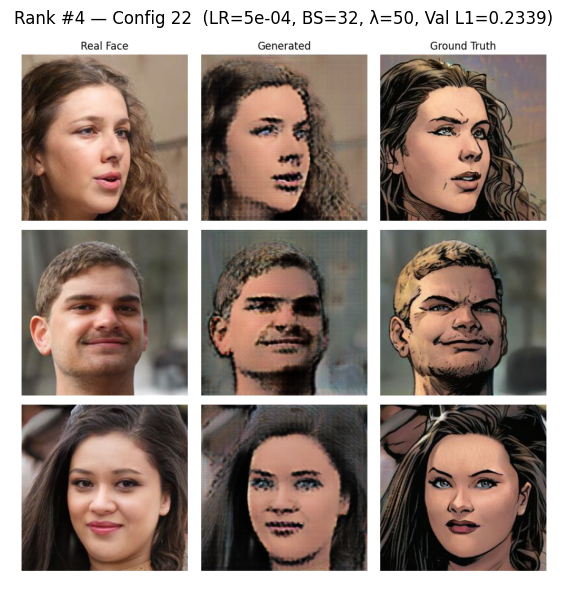

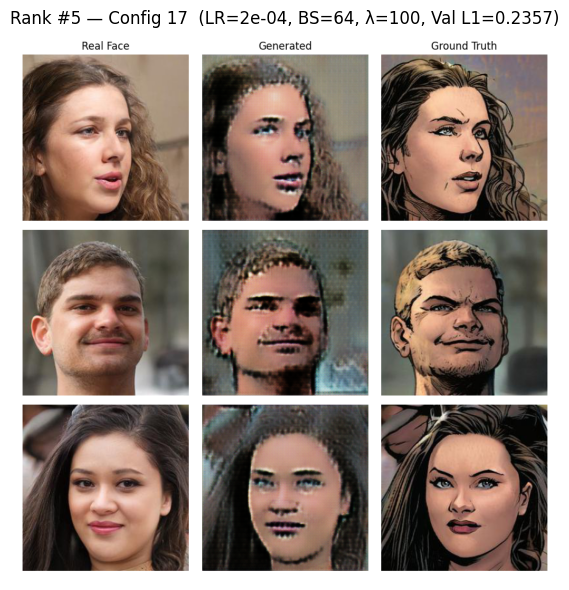

In [13]:
# Sample grid from top-3 configs
top3 = sorted(grid_results, key=lambda r: r["val_l1"])[:5]

for rank, r in enumerate(top3, 1):
    img_path = OUTPUT_DIR / f"config_{r['config_idx']:02d}.png"
    if img_path.exists():
        img = Image.open(img_path)
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.imshow(img)
        ax.set_title(f"Rank #{rank} — Config {r['config_idx']}  "
                     f"(LR={r['learning_rate']:.0e}, BS={r['batch_size']}, λ={r['lambda_l1']}, "
                     f"Val L1={r['val_l1']:.4f})")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

**Saved sample grids:** Low L1 should match **comic style + identity**; if not, trust visuals over the scalar.


## 8. Takeaways (**this repo's CSV**)
- **Best run:** config **23** — LR **5e-4**, batch **32**, **lambda_L1 = 100**, val **L1 ~0.226** (cell output / `notebooks/Output/grid_search_results/grid_search_results.csv`).
- **Marginal means:** higher LR lowers average val L1; **lambda 100** beats **50** and **150** on average here; batch interacts — use plots, not averages alone.
